In [162]:
import csv
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn
import sys
import statsmodels.api as sm
import warnings
import traceback
#from pingouin import ancova
#import pingouin as pg
from datetime import datetime, timedelta,date
import datetime as dt     
warnings.filterwarnings('ignore')
from IPython.display import HTML
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats.mstats import gmean

import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
# These are used for the chi-squared test and post hoc testing
from scipy.stats import chi2_contingency
# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False
pd.options.display.max_columns = 40
pd.options.display.min_rows = 100



In [163]:
def clr(x):
   return np.log(x) - np.log(gmean(x))

In [164]:
current_date = pd.to_datetime('today').date().strftime("%Y-%m-%d")
print(current_date)

2026-04-24


In [165]:
# Examine log_C18:3n6_3m (gamma-linolenic acid (birth-3m)), log_C20:3n6_3m (dihomo-gamma-linolenic acid (birth-3m)), log_C22:4n6_3m (adrenic acid (all-cis-docosa-7,10,13,16-tetraenoic acid) (birth-3m))

In [ ]:
# File updated on Oct 2 2023 in order to deal with erroneous zeroes in the cbc data
subjects = pd.read_csv("data/aim2_exwas_data_2024-June-11.csv")

# Remove breast milk analytes because I need to tranform them again.


to_drop = []
for col in subjects.columns:
    if ":" in col:
        to_drop.append(col)    

subjects.drop(to_drop, axis=1, inplace=True)  





In [ ]:
vitamin_d_use_df = pd.read_csv("data/vitamin_D_use_by_infant_all_sources_3m.csv")
subjects = subjects.merge(vitamin_d_use_df, on="subject_id", how="left")

In [ ]:
breast_milk_analytes = pd.read_csv("data/3m-breast-milk-analytes-data-wide.csv")
breast_milk_analytes_metadata = pd.read_csv("/metadata/3m-breast-milk-analytes-metadata.csv")
xref_to_short_name={}

for index, row in breast_milk_analytes_metadata.iterrows():
    xref_to_short_name[row['base_variable_name']]=row['short_name']
breast_milk_analytes.rename(columns=xref_to_short_name, inplace=True)

subjects = pd.merge(subjects, breast_milk_analytes, how="left", on="subject_id")

In [ ]:
# breast milk metadata
breast_milk_analytes_metadata = pd.read_csv("metadata/Milk_metadata_summary25052020.csv")
breast_milk_analytes_metadata.rename(columns={"CHILDid":"subject_id"}, inplace=True)
breast_milk_analytes_metadata = breast_milk_analytes_metadata[["subject_id", "age_milk_wks1"]]
subjects = pd.merge(subjects, breast_milk_analytes_metadata, how="left", on="subject_id")

# Remove rows where age_milk_wks1  < 10 or > 14
subjects = subjects[(subjects["age_milk_wks1"] >= 10)]

# Get mean of each of the three breast milk fatty acids

In [170]:
# Examine log_C18:3n6_3m (gamma-linolenic acid (birth-3m)), log_C20:3n6_3m (dihomo-gamma-linolenic acid (birth-3m)), log_C22:4n6_3m (adrenic acid (all-cis-docosa-7,10,13,16-tetraenoic acid) (birth-3m))
print("Mean gamma-linolenic acid (birth-3m):", np.mean(breast_milk_analytes['C18:3n6_3m']))
print("Mean dihomogamma-linolenic acid (birth-3m):", np.mean(breast_milk_analytes['C20:3n6_3m']))
print("Mean adrenic acid (birth-3m):", np.mean(breast_milk_analytes['C22:4n6_3m']))


Mean gamma-linolenic acid (birth-3m): 0.10237582502916666
Mean dihomogamma-linolenic acid (birth-3m): 0.345624843805
Mean adrenic acid (birth-3m): 0.043630791079999995


In [ ]:
ethnicity = pd.read_csv("data/parent-ethnicity-data-wide.csv")
ethnicity = ethnicity[~ethnicity['dad_race'].isna()]
ethnicity = ethnicity[~ethnicity['mom_race'].isna()]

subjects = pd.merge(subjects, ethnicity, how="left", on="subject_id")

for index, row in subjects.iterrows():
    if row['dad_race']=='Caucasian White' and row['mom_race']=='Caucasian White':
        subjects.loc[index,'caucasian_ethnicity'] = 2
    elif row['dad_race']=='Caucasian White' or row['mom_race']=='Caucasian White':
        subjects.loc[index, 'caucasian_ethnicity'] = 1
    else:
        subjects.loc[index, 'caucasian_ethnicity'] = 0

    if row['dad_race'] in ['East Asian','South East Asian','South Asian'] and row['mom_race'] in ['East Asian','South East Asian']:
        subjects.loc[index,'asian_ethnicity'] = 2
    elif row['dad_race'] in ['East Asian','South East Asian','South Asian'] or row['mom_race']  in ['East Asian','South East Asian','South Asian']:
        subjects.loc[index, 'asian_ethnicity'] = 1
    else:
        subjects.loc[index, 'asian_ethnicity'] = 0


    if row['dad_race']=='First Nations' and row['mom_race']=='First Nations':
        subjects.loc[index,'first_nations_ethnicity'] = 2
    elif row['dad_race']=='First Nations' or row['mom_race']=='First Nations':
        subjects.loc[index, 'first_nations_ethnicity'] = 1
    else:
        subjects.loc[index, 'first_nations_ethnicity'] = 0
    
subjects.reset_index(drop=True, inplace=True)
# Drop the original is_caucasian column
#subjects.drop(columns=["is_caucasian","dad_race","mom_race"], inplace=True)
# Drop the original is_asian column

In [ ]:
if 1:
    child_blood_cbc = pd.read_csv("data/child-blood-cbc-variables-wide.csv")
    child_blood_cbc_metadata = pd.read_csv("metadata/child-blood-cbc-metadata.csv")
    xref_to_short_name={}
    for index, row in child_blood_cbc_metadata.iterrows():
        suffix=""  

        if row['visit'] == 'Birth':
            suffix="birth"

        if row['visit'] == 'Prenatal 18 weeks':
            suffix="prenatal"

        if row['visit'] == '18 Months':
            suffix="18m"

        if row['visit'] == '3 Months':
            suffix="3m"

        if row['visit'] == '6 Months':
            suffix="6m"
        

        if row['visit'] == '1 Year':
            suffix="1Y"

        if row['visit'] == '2 Years':
            suffix="2Y"
        if row['visit'] == '2.5 Years':
            suffix="30m"
        if row['visit'] == '3 Years':
            suffix="3Y"
        if row['visit'] == '5 Years':
            suffix="5Y"

        
        xref_to_short_name[row['base_variable_name']]=row['short_name']+"_"+suffix
    child_blood_cbc.rename(columns=xref_to_short_name,inplace=True)

    ###### Leave it out for now ########
    subjects = pd.merge(subjects,child_blood_cbc,how="left",on="subject_id")

# Calculate mother BMI based on weight at end of pregnancy

In [ ]:
mother_bmi_df = pd.read_csv("data/mother-bmi-1y-wide.csv")

In [ ]:
mother_bmi_df.replace(to_replace="Not applicable", value=np.nan, inplace=True)
mother_bmi_df.replace(to_replace="Subject skipped the questionnaire", value=np.nan, inplace=True)
mother_bmi_df.replace(to_replace="No response to this question", value=np.nan, inplace=True)


In [ ]:
mother_bmi_df['mother_weight_kg_start_preg'] = mother_bmi_df['mother_weight_kg_start_preg'].astype(float)
mother_bmi_df['mother_weight_gain_during_preg_lb'] = mother_bmi_df['mother_weight_gain_during_preg_lb'].astype(float)
mother_bmi_df['mother_weight_gain_during_preg_kg'] = mother_bmi_df['mother_weight_gain_during_preg_kg'].astype(float)

for index, row in mother_bmi_df.iterrows():

    weight_kg_start_preg = float(row['mother_weight_kg_start_preg'])
    weight_gain_preg_kg =float(row['mother_weight_gain_during_preg_kg'])
    mother_height_cm = float(row['mother_height_cm'])


   # Calculate mother_weight_kg_start_preg using mother_weight_lb_start_preg if available
    if str(row['mother_weight_lb_start_preg']) != 'nan' and str(row['mother_weight_lb_start_preg']) != 'None':
        weight_kg_start_preg = float(row['mother_weight_lb_start_preg']) / 2.20462

        print(weight_kg_start_preg)
        mother_bmi_df.loc[index, 'mother_weight_kg_start_preg'] = weight_kg_start_preg


    if str(row['mother_weight_gain_during_preg_lb']) != 'nan' and str(row['mother_weight_gain_during_preg_lb']) != 'None':
        print(weight_gain_preg_kg)
        # Convert weight gain from pounds to kilograms
        weight_gain_preg_kg = float(row['mother_weight_gain_during_preg_lb']) / 2.20462
        mother_bmi_df.loc[index, 'mother_weight_gain_during_preg_kg'] = weight_gain_preg_kg


    mother_weight_kg_end_preg = weight_kg_start_preg + weight_gain_preg_kg
    
    if  str(mother_height_cm) != 'nan'  and str(mother_height_cm) != 'None' and str(mother_weight_kg_end_preg) != 'nan'  and str(mother_weight_kg_end_preg) != 'None': 

        mother_bmi = float(mother_weight_kg_end_preg) / ((mother_height_cm / 100) ** 2)
        mother_bmi_df.loc[index, 'mother_bmi'] = mother_bmi

mother_bmi_df.loc[index, 'mother_weight_kg_end_preg'] = mother_weight_kg_end_preg

mother_bmi_df = mother_bmi_df[~mother_bmi_df['mother_weight_kg_start_preg'].isna()]
mother_bmi_df = mother_bmi_df[['subject_id', 'mother_bmi', 'mother_weight_kg_start_preg', 'mother_weight_kg_end_preg','mother_height_cm']]


In [176]:
subjects = pd.merge(subjects,mother_bmi_df,how="left",on="subject_id")
subjects['log_adrenic_acid_3m'] = np.log10(subjects['C22:4n6_3m'])

# Are adrenic acid levels dependent on mother's BMI at time of birth?

No, there is no correlation between mother's BMI and adrenic acid percentage

<Axes: xlabel='C22:4n6_3m', ylabel='Count'>

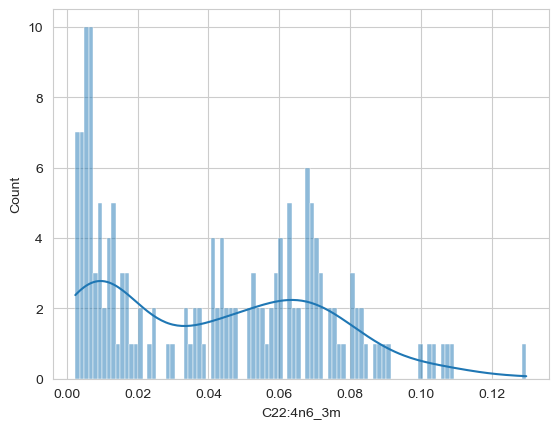

In [177]:
# Drop rows with missing data in either column
data = subjects[['mother_bmi', 'C22:4n6_3m','is_caucasian','site_toronto','site_vancouver','site_winnipeg','site_edmonton']].dropna()
data = data[data['site_edmonton'] ==1]  # Ensure no zero values for log transformation

sns.histplot(data=data,x='C22:4n6_3m',bins=100, kde=True)

<Axes: xlabel='mother_bmi', ylabel='Count'>

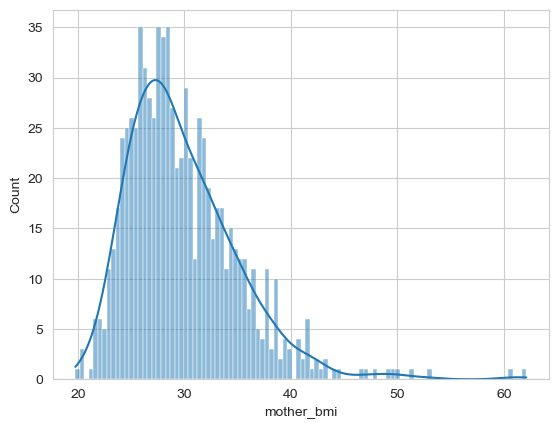

In [178]:
sns.histplot(data=subjects,x='mother_bmi',bins=100, kde=True)

In [179]:
from scipy.stats import pearsonr, spearmanr

# Drop rows with missing data in either column
data = subjects[['mother_bmi', 'C22:4n6_3m']].dropna()


# Spearman correlation
spearman_corr, spearman_p = spearmanr(data['mother_bmi'], data['C22:4n6_3m'])
print(f"Spearman correlation: rho = {spearman_corr:.3f}, p = {spearman_p:.3e}")

Spearman correlation: rho = 0.037, p = 3.071e-01


In [180]:
omega6=['C22:4n6_3m','C18:3n6_3m','C20:3n6_3m','C18:2n6_3m','C20:2n6_3m','C20:4n6_3m']
omega3 = ['C18:3n3_3m','C20:5n3_3m','22:5n6_3m','C22:5n3_3m','C22:6n3_3m']
exposures = omega6+omega3
subjects = subjects[~subjects['C22:4n6_3m'].isna()]
 # Next CLR transform the exposure after removing negative values
for col in subjects.columns:
    if col in exposures:
        subjects[col]=clr(subjects[col])
# Create an overall omega6/omega3 ratio
if 1:        
    for index, row in subjects.iterrows():
        omega6_total =  row['C22:4n6_3m']+row['C18:3n6_3m']+row['C20:3n6_3m']+row['C18:2n6_3m']+row['C20:2n6_3m']+row['C20:4n6_3m']+row['22:5n6_3m']
   
        omega3_total = row['C18:3n3_3m']+row['22:5n6_3m']+row['C22:5n3_3m']+row['C22:6n3_3m']
        
        omega6_omega3_ratio = omega6_total/omega3_total
 
        subjects.loc[index,'omega6_omega3_ratio'] = omega6_omega3_ratio



        ARA_over_EPA_plus_DHA = row['C20:4n6_3m']/(row['C20:5n3_3m']+row['C22:6n3_3m'])
        subjects.loc[index,'ARA_over_EPA_plus_DHA'] = ARA_over_EPA_plus_DHA

        
        

In [181]:
# convert PUFA proportions to standardized z-scores

# Calculate mean and standard deviation
mean = subjects['C18:3n6_3m'].mean()
std = subjects['C18:3n6_3m'].std()

# Standardize the column and add as a new column
subjects['C18:3n6_3m_zscore'] = (subjects['C18:3n6_3m'] - mean) / std

# Calculate mean and standard deviation
mean = subjects['C22:4n6_3m'].mean()
std = subjects['C22:4n6_3m'].std()

# Standardize the column and add as a new column
subjects['C22:4n6_3m_zscore'] = (subjects['C22:4n6_3m'] - mean) / std

# Calculate mean and standard deviation
mean = subjects['C20:3n6_3m'].mean()
std = subjects['C20:3n6_3m'].std()

# Standardize the column and add as a new column
subjects['C20:3n6_3m_zscore'] = (subjects['C20:3n6_3m'] - mean) / std

# DHA
mean = subjects['C22:6n3_3m'].mean()
std = subjects['C22:6n3_3m'].std()
# Standardize the column and add as a new column
subjects['C22:6n3_3m_zscore'] = (subjects['C22:6n3_3m'] - mean) / std

# ARA
mean = subjects['C20:4n6_3m'].mean()
std = subjects['C20:4n6_3m'].std()
# Standardize the column and add as a new column
subjects['C20:4n6_3m_zscore'] = (subjects['C20:4n6_3m'] - mean) / std

for index, row in subjects.iterrows():
    ara_dha_ratio = row['C20:4n6_3m_zscore']/row['C22:6n3_3m_zscore']  
    subjects.loc[index,'ARA_DHA_ratio'] = ara_dha_ratio


In [182]:
# Determine the quintile for each z-score column
subjects['C20:3n6_3m_quintile'] = pd.qcut(subjects['C20:3n6_3m_zscore'], q=5, labels=[1, 2, 3, 4, 5])
subjects['C22:4n6_3m_quintile'] = pd.qcut(subjects['C22:4n6_3m_zscore'], q=5, labels=[1, 2, 3, 4, 5])
subjects['C18:3n6_3m_quintile'] = pd.qcut(subjects['C18:3n6_3m_zscore'], q=5, labels=[1, 2, 3, 4, 5])
subjects['ARA_DHA_ratio_quintile'] = pd.qcut(subjects['ARA_DHA_ratio'], q=5, labels=[1, 2, 3, 4, 5])

subjects.rename(columns={'C20:3n6_3m_zscore':'C20_3n6_3m_zscore','C22:4n6_3m_zscore':'C22_4n6_3m_zscore','C18:3n6_3m_zscore':'C18_3n6_3m_zscore'},inplace=True)


In [183]:
# Determine if each sample is in the 5th quintile and assign 0 or 1
subjects['C20_3n6_3m_is_5th_quintile'] = (subjects['C20:3n6_3m_quintile'] == 5).astype(int)
subjects['C22_4n6_3m_is_5th_quintile'] = (subjects['C22:4n6_3m_quintile'] == 5).astype(int)
subjects['C18_3n6_3m_is_5th_quintile'] = (subjects['C18:3n6_3m_quintile'] == 5).astype(int)
subjects['ARA_DHA_ratio_is_5th_quintile'] = (subjects['ARA_DHA_ratio_quintile'] == 5).astype(int)

# Determine if each sample is in the 4th quintile and assign 0 or 1
subjects['C20_3n6_3m_is_4th_quintile'] = (subjects['C20:3n6_3m_quintile'] == 4).astype(int)
subjects['C22_4n6_3m_is_4th_quintile'] = (subjects['C22:4n6_3m_quintile'] == 4).astype(int)
subjects['C18_3n6_3m_is_4th_quintile'] = (subjects['C18:3n6_3m_quintile'] == 4).astype(int)
subjects['ARA_DHA_ratio_is_4th_quintile'] = (subjects['ARA_DHA_ratio_quintile'] == 4).astype(int)


# Determine if each sample is in the 3rd quintile and assign 0 or 1
subjects['C20_3n6_3m_is_3rd_quintile'] = (subjects['C20:3n6_3m_quintile'] == 3).astype(int)
subjects['C22_4n6_3m_is_3rd_quintile'] = (subjects['C22:4n6_3m_quintile'] == 3).astype(int)
subjects['C18_3n6_3m_is_3rd_quintile'] = (subjects['C18:3n6_3m_quintile'] == 3).astype(int)
subjects['ARA_DHA_ratio_is_3rd_quintile'] = (subjects['ARA_DHA_ratio_quintile'] == 3).astype(int)

# Determine if each sample is in the 2nd quintile and assign 0 or 1
subjects['C20_3n6_3m_is_2nd_quintile'] = (subjects['C20:3n6_3m_quintile'] == 2).astype(int)
subjects['C22_4n6_3m_is_2nd_quintile'] = (subjects['C22:4n6_3m_quintile'] == 2).astype(int)
subjects['C18_3n6_3m_is_2nd_quintile'] = (subjects['C18:3n6_3m_quintile'] == 2).astype(int)
subjects['ARA_DHA_ratio_is_2nd_quintile'] = (subjects['ARA_DHA_ratio_quintile'] == 2).astype(int)

In [184]:
# Determine if each sample is in the 1st quintile and assign 0 or 1
subjects['C20_3n6_3m_is_1st_quintile'] = (subjects['C20:3n6_3m_quintile'] == 1).astype(int)
subjects['C22_4n6_3m_is_1st_quintile'] = (subjects['C22:4n6_3m_quintile'] == 1).astype(int)
subjects['C18_3n6_3m_is_1st_quintile'] = (subjects['C18:3n6_3m_quintile'] == 1).astype(int)
subjects['ARA_DHA_ratio_is_1st_quintile'] = (subjects['ARA_DHA_ratio_quintile'] == 1).astype(int)

<Axes: xlabel='C18_3n6_3m_zscore', ylabel='Count'>

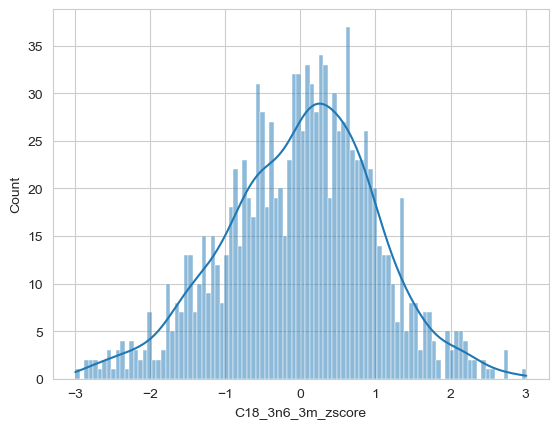

In [185]:
sns.histplot(data=subjects,x='C18_3n6_3m_zscore',bins=100, kde=True)

<Axes: xlabel='age_milk_wks1', ylabel='Count'>

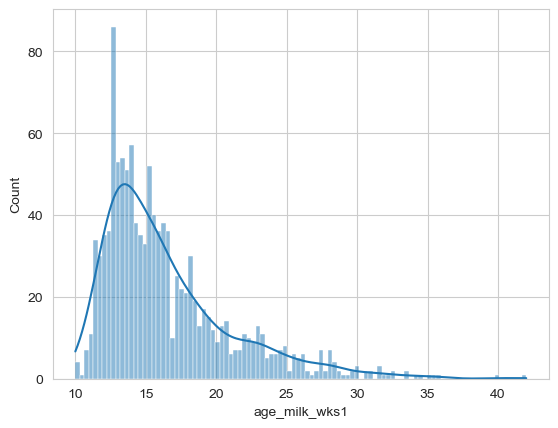

In [186]:
sns.histplot(data=subjects,x='age_milk_wks1',bins=100, kde=True)

In [187]:
exposures=['C20_3n6_3m_is_5th_quintile','C22_4n6_3m_is_5th_quintile','C18_3n6_3m_is_5th_quintile']

covariates = ['is_male','age_milk_wks1','EBF_3m','vaginal_birth','family_asthma_history','num_antibiotic_courses_birth_to_1y','total_household_income_PR18WK','site_toronto', 'site_vancouver', 'site_edmonton','caucasian_ethnicity','asian_ethnicity','first_nations_ethnicity']

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','male_or_female','family_asthma_history','exposure','covariate','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value','significant'])

#outcomes =['recurrent_wheeze_binary_1y','asthma_3y','asthma_5y','asthma_8y','food_binary_1y','food_binary_3y','atopic_dermatitis_status_1y','atopic_dermatitis_status_3y','recurrent_wheeze_binary_5y','food_binary_5y','atopic_dermatitis_status_5y']
outcomes =['food_binary_3y','asthma_3y','asthma_5y','asthma_8y']

for outcome in outcomes:

    for exposure in exposures:
        

        if exposure not in covariates:


            if 1:

                print(exposure)
                #### First look at males
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append(exposure)

                adjusted_data_columns = adjusted_data_columns + covariates       
                print(adjusted_data_columns )    
                adjusted_data = subjects.copy()     
                adjusted_data = adjusted_data[adjusted_data_columns]
                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]
                adjusted_data= adjusted_data[~adjusted_data[exposure].isna()]
                adjusted_data= adjusted_data[adjusted_data['is_male']==1]

                male_or_female = 'Male'

            
                adjusted_data.drop(columns=['is_male'],inplace=True)
            
                    

                total_cases = adjusted_data[adjusted_data[outcome]==1]
                total_cases_exposed = total_cases[total_cases[exposure]!=0]
                   
                adjusted_data = adjusted_data.fillna(adjusted_data.median())                
                total_exposures = adjusted_data[adjusted_data[exposure]!=0]

                

                model = sm.formula.logit(outcome + ' ~ caucasian_ethnicity + asian_ethnicity + first_nations_ethnicity + age_milk_wks1 + num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton + '+ exposure , data=adjusted_data).fit()
                print(model.summary())

                odds_ratios = pd.DataFrame(
                                            {
                                                "OR": model.params,
                                                "Lower CI": model.conf_int()[0],
                                                "Upper CI": model.conf_int()[1]
                                            }
                                        )
                odds_ratios = np.exp(odds_ratios)

                odds_ratios['P-value'] = round(model.pvalues,4)

                odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                odds_ratios['OR'] = round(odds_ratios['OR'],2)

                odds_ratios = odds_ratios.loc[exposure]    
                significant_effect_row = odds_ratios.to_dict()
                if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                elif significant_effect_row['P-value']<0.01:
                    significant_effect_row['significant']="**"
                else:
                    significant_effect_row['significant']=""

                significant_effect_row['outcome']= outcome
                if exposure in covariates:
                    significant_effect_row['covariate']="Yes"
                else:
                    significant_effect_row['covariate']=""
                
                significant_effect_row['exposure']=exposure
                significant_effect_row['male_or_female']=male_or_female


                if "_8y" in outcome:                         
                    significant_effect_row['time outcome assessed']='8 years'   
                if "_5y" in outcome:                         
                    significant_effect_row['time outcome assessed']='5 years'
                if "_3y" in outcome:                         
                    significant_effect_row['time outcome assessed']='3 years'
                if "_1y" in outcome:                         
                    significant_effect_row['time outcome assessed']='1 year'
                
                
                #significant_effect_row['is_male']=is_male
                significant_effect_row['total cases']=len(total_cases)
                significant_effect_row['total exposures']=len(total_exposures)
                significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                significant_effect_row['total children']=len(adjusted_data)
                odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                #### Then look at females
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append(exposure)

                adjusted_data_columns = adjusted_data_columns + covariates                
                adjusted_data = subjects.copy()     
                adjusted_data = adjusted_data[adjusted_data_columns]
                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]
                adjusted_data= adjusted_data[~adjusted_data[exposure].isna()]
                adjusted_data= adjusted_data[adjusted_data['is_male']==0]

                male_or_female = 'Female'

            
                adjusted_data.drop(columns=['is_male'],inplace=True)
            
                    

                total_cases = adjusted_data[adjusted_data[outcome]==1]
                total_cases_exposed = total_cases[total_cases[exposure]!=0]

                adjusted_data = adjusted_data.fillna(adjusted_data.median())                
                total_exposures = adjusted_data[adjusted_data[exposure]!=0]

                model = sm.formula.logit(outcome + ' ~ caucasian_ethnicity + asian_ethnicity + first_nations_ethnicity + age_milk_wks1 + num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton + '+ exposure , data=adjusted_data).fit()

                print(model.summary())
                odds_ratios = pd.DataFrame(
                                            {
                                                "OR": model.params,
                                                "Lower CI": model.conf_int()[0],
                                                "Upper CI": model.conf_int()[1]
                                            }
                                        )
                odds_ratios = np.exp(odds_ratios)

                odds_ratios['P-value'] = round(model.pvalues,4)
                #odds_ratios[odds_ratios['P-value']<0.05]
                odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                odds_ratios['OR'] = round(odds_ratios['OR'],2)

                odds_ratios = odds_ratios.loc[exposure]    
                significant_effect_row = odds_ratios.to_dict()
                if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                elif significant_effect_row['P-value']<0.01:
                    significant_effect_row['significant']="**"
                else:
                    significant_effect_row['significant']=""

                significant_effect_row['outcome']= outcome
                if exposure in covariates:
                    significant_effect_row['covariate']="Yes"
                else:
                    significant_effect_row['covariate']=""
                
                significant_effect_row['exposure']=exposure
                significant_effect_row['male_or_female']=male_or_female

                if "_8y" in outcome:                         
                    significant_effect_row['time outcome assessed']='8 years'        
                if "_5y" in outcome:                         
                    significant_effect_row['time outcome assessed']='5 years'
                if "_3y" in outcome:                         
                    significant_effect_row['time outcome assessed']='3 years'
                if "_1y" in outcome:                         
                    significant_effect_row['time outcome assessed']='1 year'
                
        
                significant_effect_row['total cases']=len(total_cases)
                significant_effect_row['total exposures']=len(total_exposures)
                significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                significant_effect_row['total children']=len(adjusted_data)
                odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                 #### Then look at both males and female AND family asthma history
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append(exposure)

                adjusted_data_columns = adjusted_data_columns + covariates                
                adjusted_data = subjects[adjusted_data_columns]
                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]
                adjusted_data= adjusted_data[~adjusted_data[exposure].isna()]
                
          

              
        
                if 1:
                    #### Then look at all children
                    adjusted_data_columns = []

                    adjusted_data_columns.append(outcome)
                    adjusted_data_columns.append(exposure)

                    adjusted_data_columns = adjusted_data_columns + covariates                
                    adjusted_data = subjects.copy()     
                    adjusted_data = adjusted_data[adjusted_data_columns]
                    adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]
                    adjusted_data= adjusted_data[~adjusted_data[exposure].isna()]
                    
                    male_or_female = 'All'              
                    
                
                        

                    total_cases = adjusted_data[adjusted_data[outcome]==1]
                    total_cases_exposed = total_cases[total_cases[exposure]!=0]

                    adjusted_data = adjusted_data.fillna(adjusted_data.median())                
                    total_exposures = adjusted_data[adjusted_data[exposure]!=0]

                    model = sm.formula.logit(outcome + ' ~ caucasian_ethnicity + asian_ethnicity + first_nations_ethnicity + age_milk_wks1 + num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton + is_male + '+ exposure , data=adjusted_data).fit()

                    print(model.summary())
                    odds_ratios = pd.DataFrame(
                                                {
                                                    "OR": model.params,
                                                    "Lower CI": model.conf_int()[0],
                                                    "Upper CI": model.conf_int()[1]
                                                }
                                            )
                    odds_ratios = np.exp(odds_ratios)

                    odds_ratios['P-value'] = round(model.pvalues,4)
                    #odds_ratios[odds_ratios['P-value']<0.05]
                    odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                    odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                    odds_ratios['OR'] = round(odds_ratios['OR'],2)

                    odds_ratios = odds_ratios.loc[exposure]    
                    significant_effect_row = odds_ratios.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['outcome']= outcome
                    if exposure in covariates:
                        significant_effect_row['covariate']="Yes"
                    else:
                        significant_effect_row['covariate']=""
                    
                    significant_effect_row['exposure']=exposure
                    significant_effect_row['male_or_female']=male_or_female

                    if "_8y" in outcome:                         
                        significant_effect_row['time outcome assessed']='8 years'        
                    if "_5y" in outcome:                         
                        significant_effect_row['time outcome assessed']='5 years'
                    if "_3y" in outcome:                         
                        significant_effect_row['time outcome assessed']='3 years'
                    if "_1y" in outcome:                         
                        significant_effect_row['time outcome assessed']='1 year'
                    
            
                    significant_effect_row['total cases']=len(total_cases)
                    significant_effect_row['total exposures']=len(total_exposures)
                    significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                    significant_effect_row['total children']=len(adjusted_data)
                    odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                    #### Then look at both males and female AND family asthma history
                    adjusted_data_columns = []

                    adjusted_data_columns.append(outcome)
                    adjusted_data_columns.append(exposure)

                    adjusted_data_columns = adjusted_data_columns + covariates                
                    adjusted_data = subjects[adjusted_data_columns]
                    adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]
                    adjusted_data= adjusted_data[~adjusted_data[exposure].isna()]




              








C20_3n6_3m_is_5th_quintile
['food_binary_3y', 'C20_3n6_3m_is_5th_quintile', 'is_male', 'age_milk_wks1', 'EBF_3m', 'vaginal_birth', 'family_asthma_history', 'num_antibiotic_courses_birth_to_1y', 'total_household_income_PR18WK', 'site_toronto', 'site_vancouver', 'site_edmonton', 'caucasian_ethnicity', 'asian_ethnicity', 'first_nations_ethnicity']
Optimization terminated successfully.
         Current function value: 0.313331
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         food_binary_3y   No. Observations:                  590
Model:                          Logit   Df Residuals:                      580
Method:                           MLE   Df Model:                            9
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.1146
Time:                        20:56:57   Log-Likelihood:                -184.87
converged:                       True   LL-Null:                       -208.8

In [188]:
import statsmodels.stats.multitest


frames = []

for div_index in exposures:

    

    temp = odds_ratio_table[odds_ratio_table['exposure']==div_index]
    temp = temp[temp['P-value'].notna()]
            
    if len(temp)>0:
        

        outcomes = temp['outcome'].unique()

        for outcome in outcomes:
                
                temp2 = temp[temp['outcome']==outcome]
                
                # Perform multiple testing to get q value
                reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp2['P-value'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
                        # Adds the q-value (correct p-value) and Pass/Fail to the data frame
                temp2['q']=q
                temp2['reject_null']=reject
        


                div_index = div_index.replace(" ","_")
                
                frames.append(temp2)
                
                #temp.to_csv("olink/exposures/olink-all-exposure-5y-"+div_index+".csv",index=False)


In [189]:
temp2

,time outcome assessed,outcome,male_or_female,family_asthma_history,exposure,covariate,total children,total cases,total exposures,total cases with exposure,OR,Lower CI,Upper CI,P-value,significant,q,reject_null
33,8 years,asthma_8y,Male,NaN,C18_3n6_3m_is_5th_quintile,,487,39,99,8,0.97,0.41,2.25,0.9349,,0.93490,False
34,8 years,asthma_8y,Female,NaN,C18_3n6_3m_is_5th_quintile,,424,31,76,10,2.50,1.07,5.84,0.0346,*,0.10380,False
35,8 years,asthma_8y,All,NaN,C18_3n6_3m_is_5th_quintile,,911,70,175,18,1.48,0.82,2.67,0.1901,,0.28515,False


In [190]:
odds_ratio_table = pd.concat(frames)
tmp = odds_ratio_table.copy()
tmp = tmp[tmp['outcome']!='food_binary_3y']
tmp = tmp.replace(np.nan,"")
tmp[tmp['P-value']<0.9].sort_values(by=['outcome','exposure'])


,time outcome assessed,outcome,male_or_female,family_asthma_history,exposure,covariate,total children,total cases,total exposures,total cases with exposure,OR,Lower CI,Upper CI,P-value,significant,q,reject_null
15,3 years,asthma_3y,Male,,C18_3n6_3m_is_5th_quintile,,529,69,104,17,1.74,0.91,3.34,0.0949,,0.09490,False
16,3 years,asthma_3y,Female,,C18_3n6_3m_is_5th_quintile,,444,38,82,14,4.63,2.00,10.68,0.0003,**,0.00090,True
17,3 years,asthma_3y,All,,C18_3n6_3m_is_5th_quintile,,973,107,186,31,2.41,1.46,3.98,0.0006,**,0.00090,True
9,3 years,asthma_3y,Male,,C20_3n6_3m_is_5th_quintile,,529,69,97,22,3.10,1.60,5.98,0.0008,**,0.00120,True
10,3 years,asthma_3y,Female,,C20_3n6_3m_is_5th_quintile,,444,38,78,10,2.19,0.91,5.28,0.0810,,0.08100,False
11,3 years,asthma_3y,All,,C20_3n6_3m_is_5th_quintile,,973,107,175,32,2.77,1.64,4.67,0.0001,**,0.00030,True
12,3 years,asthma_3y,Male,,C22_4n6_3m_is_5th_quintile,,529,69,98,20,2.19,1.15,4.15,0.0166,*,0.01660,True
13,3 years,asthma_3y,Female,,C22_4n6_3m_is_5th_quintile,,444,38,74,12,3.64,1.58,8.39,0.0024,**,0.00360,True
14,3 years,asthma_3y,All,,C22_4n6_3m_is_5th_quintile,,973,107,172,32,2.59,1.57,4.27,0.0002,**,0.00060,True
24,5 years,asthma_5y,Male,,C18_3n6_3m_is_5th_quintile,,512,72,99,16,1.15,0.62,2.14,0.6674,,0.66740,False


In [191]:
from matplotlib.ticker import FuncFormatter

# Create a function to format the tick labels with decimal notation
def log_fmt(x, pos):
    if x >= 1:
        return f"{x:.1f}"
    else:
        return f"{x:.1e}"

# Association between being in the upper quinitile for 3 fatty acids (controlling for each others levels) and development of 5- and 8-year asthma

In [192]:
exposures=['C20_3n6_3m_is_5th_quintile','C22_4n6_3m_is_5th_quintile','C18_3n6_3m_is_5th_quintile']

covariates = ['is_male','age_milk_wks1','prenatal_smoke_exposure','vaginal_birth','family_asthma_history','num_antibiotic_courses_birth_to_1y','total_household_income_PR18WK','site_toronto', 'site_vancouver', 'site_edmonton','caucasian_ethnicity']

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','male_or_female','family_asthma_history','exposure','covariate','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value','significant'])

odds_ratio_table_B = pd.DataFrame(columns=['time outcome assessed','outcome','male_or_female','family_asthma_history','exposure','covariate','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value','significant'])


#outcomes =['recurrent_wheeze_binary_1y','asthma_3y','asthma_5y','asthma_8y','food_binary_1y','food_binary_3y','atopic_dermatitis_status_1y','atopic_dermatitis_status_3y','recurrent_wheeze_binary_5y','food_binary_5y','atopic_dermatitis_status_5y']
outcomes =['recurrent_wheeze_binary_1y','asthma_3y','asthma_5y','asthma_8y']

for outcome in outcomes:

    if 1:
        
        exposure = 'C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile'

        if exposure not in covariates:


            if 1:

                #### First look at males and females together
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append("C20_3n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C22_4n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C18_3n6_3m_is_5th_quintile")


                adjusted_data_columns = adjusted_data_columns + covariates       
                print(adjusted_data_columns )    
                adjusted_data = subjects.copy()     
                adjusted_data = adjusted_data[~adjusted_data["C20_3n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C22_4n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C18_3n6_3m_is_5th_quintile"].isna()]
                               
                
                #adjusted_data = adjusted_data[~adjusted_data["vitamin_D_taken_by_infant_3m"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["prenatal_smoke_exposure"].isna()]
                
                adjusted_data = adjusted_data[~adjusted_data["family_asthma_history"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["total_household_income_PR18WK"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["vaginal_birth"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["caucasian_ethnicity"].isna()]
                #adjusted_data = adjusted_data[~adjusted_data["asian_ethnicity"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["age_milk_wks1"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["num_antibiotic_courses_birth_to_1y"].isna()]
                adjusted_data = adjusted_data[~adjusted_data['summer_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['winter_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['autumn_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_male'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_caucasian'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_toronto'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_vancouver'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_edmonton'].isna()]

                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]

             

                male_or_female = 'Both'

            
                   
                #adjusted_data = adjusted_data.fillna(adjusted_data.median())                


                

                model = sm.formula.logit(outcome + ' ~ is_male  + prenatal_smoke_exposure + family_asthma_history + total_household_income_PR18WK + vaginal_birth + caucasian_ethnicity +  age_milk_wks1 + num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton +  C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile' , data=adjusted_data).fit()
                print(model.summary())

                for exposure in exposures:
                    odds_ratios = pd.DataFrame(
                                            {
                                                "OR": model.params,
                                                "Lower CI": model.conf_int()[0],
                                                "Upper CI": model.conf_int()[1]
                                            }
                                        )
                    odds_ratios = np.exp(odds_ratios)

                    odds_ratios['P-value'] = round(model.pvalues,4)

                    odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                    odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                    odds_ratios['OR'] = round(odds_ratios['OR'],2)

                    odds_ratios = odds_ratios.loc[exposure]   
                    significant_effect_row = odds_ratios.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['outcome']= outcome
                    if exposure in covariates:
                        significant_effect_row['covariate']="Yes"
                    else:
                        significant_effect_row['covariate']=""
                    
                    significant_effect_row['exposure']=exposure
                    significant_effect_row['male_or_female']=male_or_female


                    if "_8y" in outcome:                         
                        significant_effect_row['time outcome assessed']='8 years'   
                    if "_5y" in outcome:                         
                        significant_effect_row['time outcome assessed']='5 years'
                    if "_3y" in outcome:                         
                        significant_effect_row['time outcome assessed']='3 years'
                    if "_1y" in outcome:                         
                        significant_effect_row['time outcome assessed']='1 year'
                
                
                    #significant_effect_row['is_male']=is_male
                    significant_effect_row['total cases']=len(total_cases)
                    significant_effect_row['total exposures']=len(total_exposures)
                    significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                    significant_effect_row['total children']=len(adjusted_data)
                    odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                # Create another dataframe for the same analysis but with all of the covariates included
                for col in adjusted_data_columns:
                    print(col)

                    if col !=outcome and col in adjusted_data.columns:

                        odds_ratios = pd.DataFrame(
                                                {
                                                    "OR": model.params,
                                                    "Lower CI": model.conf_int()[0],
                                                    "Upper CI": model.conf_int()[1]
                                                }
                                            )
                        odds_ratios = np.exp(odds_ratios)

                        odds_ratios['P-value'] = round(model.pvalues,4)

                        odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                        odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                        odds_ratios['OR'] = round(odds_ratios['OR'],2)

                        odds_ratios = odds_ratios.loc[col]   
                        significant_effect_row = odds_ratios.to_dict()
                        if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                                significant_effect_row['significant']="*"
                        elif significant_effect_row['P-value']<0.01:
                            significant_effect_row['significant']="**"
                        else:
                            significant_effect_row['significant']=""

                        significant_effect_row['outcome']= outcome
                        if col in covariates:
                            significant_effect_row['covariate']="Yes"
                        else:
                            significant_effect_row['covariate']=""
                        
                        significant_effect_row['exposure']=col
                        significant_effect_row['male_or_female']=male_or_female


                        if "_8y" in outcome:                         
                            significant_effect_row['time outcome assessed']='8 years'   
                        if "_5y" in outcome:                         
                            significant_effect_row['time outcome assessed']='5 years'
                        if "_3y" in outcome:                         
                            significant_effect_row['time outcome assessed']='3 years'
                        if "_1y" in outcome:                         
                            significant_effect_row['time outcome assessed']='1 year'
                    
                    
                        #significant_effect_row['is_male']=is_male
                        significant_effect_row['total cases']=len(total_cases)
                        significant_effect_row['total exposures']=len(total_exposures)
                        significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                        significant_effect_row['total children']=len(adjusted_data)
                        odds_ratio_table_B.loc[len(odds_ratio_table_B)] = significant_effect_row



 
                #### Next look at males
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append("C20_3n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C22_4n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C18_3n6_3m_is_5th_quintile")


                adjusted_data_columns = adjusted_data_columns + covariates       
                print(adjusted_data_columns )    
                adjusted_data = subjects.copy()     
                adjusted_data = adjusted_data[~adjusted_data["C20_3n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C22_4n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C18_3n6_3m_is_5th_quintile"].isna()]
                                
                #adjusted_data = adjusted_data[~adjusted_data["vitamin_D_taken_by_infant_3m"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["prenatal_smoke_exposure"].isna()]
                
                adjusted_data = adjusted_data[~adjusted_data["family_asthma_history"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["total_household_income_PR18WK"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["vaginal_birth"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["caucasian_ethnicity"].isna()]
                #adjusted_data = adjusted_data[~adjusted_data["asian_ethnicity"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["age_milk_wks1"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["num_antibiotic_courses_birth_to_1y"].isna()]
                adjusted_data = adjusted_data[~adjusted_data['summer_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['winter_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['autumn_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_male'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_caucasian'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_toronto'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_vancouver'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_edmonton'].isna()]
                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]

                adjusted_data= adjusted_data[adjusted_data['is_male']==1]

                male_or_female = 'Male'

            
                adjusted_data.drop(columns=['is_male'],inplace=True)
                   
                #adjusted_data = adjusted_data.fillna(adjusted_data.median())                


                

                model = sm.formula.logit(outcome + ' ~ family_asthma_history  + prenatal_smoke_exposure + total_household_income_PR18WK + vaginal_birth + caucasian_ethnicity  + age_milk_wks1 + num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton +  C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile' , data=adjusted_data).fit()
                print(model.summary())

                for exposure in exposures:
                    odds_ratios = pd.DataFrame(
                                            {
                                                "OR": model.params,
                                                "Lower CI": model.conf_int()[0],
                                                "Upper CI": model.conf_int()[1]
                                            }
                                        )
                    odds_ratios = np.exp(odds_ratios)

                    odds_ratios['P-value'] = round(model.pvalues,4)

                    odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                    odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                    odds_ratios['OR'] = round(odds_ratios['OR'],2)

                    odds_ratios = odds_ratios.loc[exposure]   
                    significant_effect_row = odds_ratios.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['outcome']= outcome
                    if exposure in covariates:
                        significant_effect_row['covariate']="Yes"
                    else:
                        significant_effect_row['covariate']=""
                    
                    significant_effect_row['exposure']=exposure
                    significant_effect_row['male_or_female']=male_or_female


                    if "_8y" in outcome:                         
                        significant_effect_row['time outcome assessed']='8 years'   
                    if "_5y" in outcome:                         
                        significant_effect_row['time outcome assessed']='5 years'
                    if "_3y" in outcome:                         
                        significant_effect_row['time outcome assessed']='3 years'
                    if "_1y" in outcome:                         
                        significant_effect_row['time outcome assessed']='1 year'
                
                
                    #significant_effect_row['is_male']=is_male
                    significant_effect_row['total cases']=len(total_cases)
                    significant_effect_row['total exposures']=len(total_exposures)
                    significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                    significant_effect_row['total children']=len(adjusted_data)
                    odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                #### Then look at females
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append("C20_3n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C22_4n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C18_3n6_3m_is_5th_quintile")

                adjusted_data_columns = adjusted_data_columns + covariates                
                adjusted_data = subjects.copy()     
                adjusted_data = adjusted_data[~adjusted_data["C20_3n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C22_4n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C18_3n6_3m_is_5th_quintile"].isna()]
                               
                #adjusted_data = adjusted_data[~adjusted_data["vitamin_D_taken_by_infant_3m"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["prenatal_smoke_exposure"].isna()]
                
                adjusted_data = adjusted_data[~adjusted_data["family_asthma_history"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["total_household_income_PR18WK"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["vaginal_birth"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["caucasian_ethnicity"].isna()]
                #adjusted_data = adjusted_data[~adjusted_data["asian_ethnicity"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["age_milk_wks1"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["num_antibiotic_courses_birth_to_1y"].isna()]
                adjusted_data = adjusted_data[~adjusted_data['summer_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['winter_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['autumn_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_male'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_caucasian'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_toronto'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_vancouver'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_edmonton'].isna()]
               
               
                adjusted_data = adjusted_data[adjusted_data_columns]
                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]

                adjusted_data= adjusted_data[adjusted_data['is_male']==0]

                male_or_female = 'Female'

           
                adjusted_data.drop(columns=['is_male'],inplace=True)
            
                

                #adjusted_data = adjusted_data.fillna(adjusted_data.median())                
 

                model = sm.formula.logit(outcome + ' ~ family_asthma_history + prenatal_smoke_exposure + total_household_income_PR18WK + vaginal_birth + caucasian_ethnicity +  age_milk_wks1 + num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton +  C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile' , data=adjusted_data).fit()

                print(model.summary())
                for exposure in exposures:
                    odds_ratios = pd.DataFrame(
                                            {
                                                "OR": model.params,
                                                "Lower CI": model.conf_int()[0],
                                                "Upper CI": model.conf_int()[1]
                                            }
                                        )
                    odds_ratios = np.exp(odds_ratios)

                    odds_ratios['P-value'] = round(model.pvalues,4)

                    odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                    odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                    odds_ratios['OR'] = round(odds_ratios['OR'],2)
                    odds_ratios = odds_ratios.loc[exposure]    
                    significant_effect_row = odds_ratios.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['outcome']= outcome
                    if exposure in covariates:
                        significant_effect_row['covariate']="Yes"
                    else:
                        significant_effect_row['covariate']=""
                    
                    significant_effect_row['exposure']=exposure
                    significant_effect_row['male_or_female']=male_or_female

                    if "_8y" in outcome:                         
                        significant_effect_row['time outcome assessed']='8 years'        
                    if "_5y" in outcome:                         
                        significant_effect_row['time outcome assessed']='5 years'
                    if "_3y" in outcome:                         
                        significant_effect_row['time outcome assessed']='3 years'
                    if "_1y" in outcome:                         
                        significant_effect_row['time outcome assessed']='1 year'
                    
            
                    significant_effect_row['total cases']=len(total_cases)
                    significant_effect_row['total exposures']=len(total_exposures)
                    significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                    significant_effect_row['total children']=len(adjusted_data)
                    odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                
              
        
               

['recurrent_wheeze_binary_1y', 'C20_3n6_3m_is_5th_quintile', 'C22_4n6_3m_is_5th_quintile', 'C18_3n6_3m_is_5th_quintile', 'is_male', 'age_milk_wks1', 'prenatal_smoke_exposure', 'vaginal_birth', 'family_asthma_history', 'num_antibiotic_courses_birth_to_1y', 'total_household_income_PR18WK', 'site_toronto', 'site_vancouver', 'site_edmonton', 'caucasian_ethnicity']
Optimization terminated successfully.
         Current function value: 0.281205
         Iterations 7
                               Logit Regression Results                               
Dep. Variable:     recurrent_wheeze_binary_1y   No. Observations:                 1117
Model:                                  Logit   Df Residuals:                     1102
Method:                                   MLE   Df Model:                           14
Date:                        Fri, 24 Apr 2026   Pseudo R-squ.:                 0.08588
Time:                                20:56:59   Log-Likelihood:                -314.11
converged:   

In [193]:
from matplotlib.ticker import FuncFormatter

# Create a function to format the tick labels with decimal notation
def log_fmt(x, pos):
    if x >= 1:
        return f"{x:.1f}"
    else:
        return f"{x:.1e}"

## Supplementary figure 14: Create a figure showing factors associated with 5-year asthma

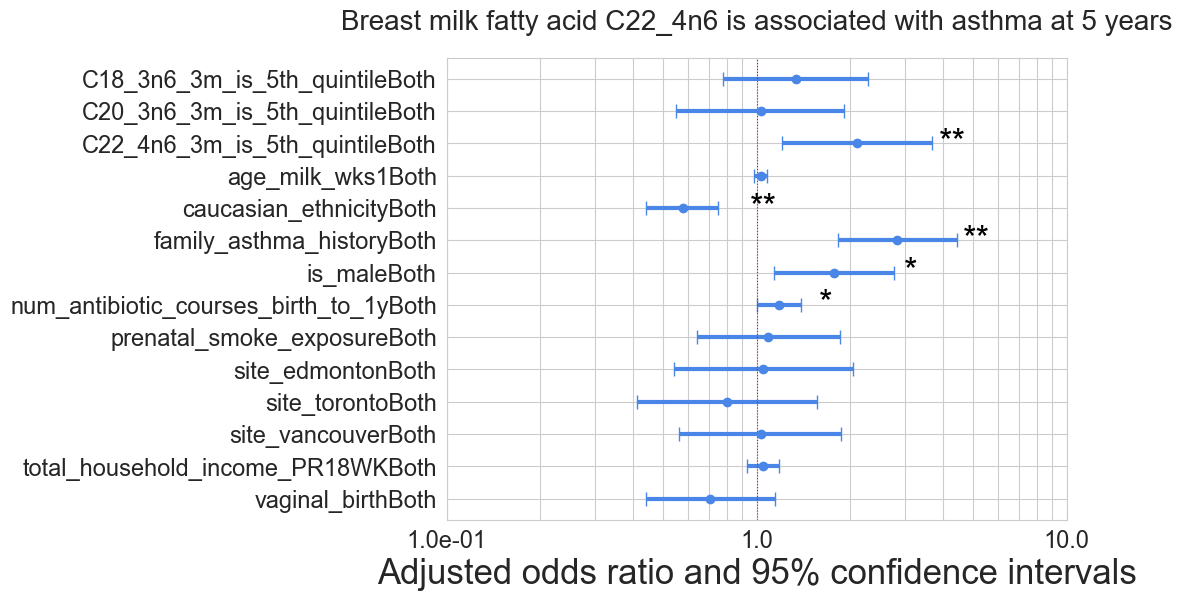

In [194]:

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(8,6))
plt.title("Breast milk fatty acid C22_4n6 is associated with asthma at 5 years",fontsize=20, pad=20)
odds_ratio_table_B.sort_values(by=["exposure"],inplace=True)
for idx, row in odds_ratio_table_B.iloc[::-1].iterrows():

    if row['outcome']=='asthma_5y':    
        
        if row['time outcome assessed']=='5 years' and row['total cases with exposure']>=5:
 
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if 1:
                label = str(row['OR'])

                
                plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='#4a86e8', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="#4a86e8", mec="#4a86e8")
                 #if row['male_or_female']=='All':
                #    plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='magenta', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="magenta", mec="magenta")
                
            
                if row['P-value']<0.01:
                    #label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure']) + ", p="+str(row['P-value'])+" *"
                    label = "**"
                elif row['P-value']<0.05:
                    label = "*"
                else:
                    #label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure']) + ", p="+str(row['P-value'])
                    label = ""
                # Add text to the right of the error bar
                plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure']+ row['male_or_female'], f'{label}', color='black', va='center', fontsize=25)

plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')
plt.xlim(0.1,10)
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=17)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=25)


plt.show()

# Figures 5a and 5b (Sex-dependent association with breast milk fatty acids )

Illustrating sex-specific association between adrenic acid and 5- and 8-year asthma while controlling for maternal BMI, infant age at sample collection, caucasian ancestry

In [195]:
exposures=['C20_3n6_3m_is_5th_quintile','C22_4n6_3m_is_5th_quintile','C18_3n6_3m_is_5th_quintile']

covariates = ['is_male','age_milk_wks1','mother_bmi','prenatal_smoke_exposure','vaginal_birth','family_asthma_history','num_antibiotic_courses_birth_to_1y','total_household_income_PR18WK','site_toronto', 'site_vancouver', 'site_edmonton','caucasian_ethnicity']

odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','outcome','male_or_female','family_asthma_history','exposure','covariate','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value','significant'])

odds_ratio_table_B = pd.DataFrame(columns=['time outcome assessed','outcome','male_or_female','family_asthma_history','exposure','covariate','total children','total cases','total exposures','total cases with exposure','OR','Lower CI', 'Upper CI','P-value','significant'])


#outcomes =['recurrent_wheeze_binary_1y','asthma_3y','asthma_5y','asthma_8y','food_binary_1y','food_binary_3y','atopic_dermatitis_status_1y','atopic_dermatitis_status_3y','recurrent_wheeze_binary_5y','food_binary_5y','atopic_dermatitis_status_5y']
outcomes =['recurrent_wheeze_binary_1y','asthma_3y','asthma_5y','asthma_8y']

for outcome in outcomes:

    if 1:
        
        exposure = 'C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile'

        if exposure not in covariates:


            if 1:

                #### First look at males and females together
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append("C20_3n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C22_4n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C18_3n6_3m_is_5th_quintile")


                adjusted_data_columns = adjusted_data_columns + covariates       
                print(adjusted_data_columns )    
                adjusted_data = subjects.copy()     
                adjusted_data = adjusted_data[~adjusted_data["C20_3n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C22_4n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C18_3n6_3m_is_5th_quintile"].isna()]
                               
                
                adjusted_data = adjusted_data[~adjusted_data["mother_bmi"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["prenatal_smoke_exposure"].isna()]
                
                adjusted_data = adjusted_data[~adjusted_data["family_asthma_history"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["total_household_income_PR18WK"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["vaginal_birth"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["caucasian_ethnicity"].isna()]

                adjusted_data = adjusted_data[~adjusted_data["age_milk_wks1"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["num_antibiotic_courses_birth_to_1y"].isna()]
                adjusted_data = adjusted_data[~adjusted_data['summer_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['winter_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['autumn_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_male'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_caucasian'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_toronto'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_vancouver'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_edmonton'].isna()]

                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]


                total_cases = adjusted_data[adjusted_data[outcome]==1]
                total_cases_exposed = total_cases[total_cases['C20_3n6_3m_is_5th_quintile']!=0]

             

                male_or_female = 'Both'

                print(outcome+ " - " + male_or_female)

            
                   
                #adjusted_data = adjusted_data.fillna(adjusted_data.median())                


                

                model = sm.formula.logit(outcome + ' ~ is_male  + prenatal_smoke_exposure + family_asthma_history + total_household_income_PR18WK + vaginal_birth + caucasian_ethnicity + age_milk_wks1 + mother_bmi + num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton +  C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile' , data=adjusted_data).fit()
                print(model.summary())

                for exposure in exposures:
                    odds_ratios = pd.DataFrame(
                                            {
                                                "OR": model.params,
                                                "Lower CI": model.conf_int()[0],
                                                "Upper CI": model.conf_int()[1]
                                            }
                                        )
                    odds_ratios = np.exp(odds_ratios)

                    odds_ratios['P-value'] = round(model.pvalues,4)

                    odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                    odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                    odds_ratios['OR'] = round(odds_ratios['OR'],2)

                    odds_ratios = odds_ratios.loc[exposure]   
                    significant_effect_row = odds_ratios.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['outcome']= outcome
                    if exposure in covariates:
                        significant_effect_row['covariate']="Yes"
                    else:
                        significant_effect_row['covariate']=""
                    
                    significant_effect_row['exposure']=exposure
                    significant_effect_row['male_or_female']=male_or_female


                    if "_8y" in outcome:                         
                        significant_effect_row['time outcome assessed']='8 years'   
                    if "_5y" in outcome:                         
                        significant_effect_row['time outcome assessed']='5 years'
                    if "_3y" in outcome:                         
                        significant_effect_row['time outcome assessed']='3 years'
                    if "_1y" in outcome:                         
                        significant_effect_row['time outcome assessed']='1 year'
                
                
                    #significant_effect_row['is_male']=is_male
                    significant_effect_row['total cases']=len(total_cases)
                    significant_effect_row['total exposures']=len(total_exposures)
                    significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                    significant_effect_row['total children']=len(adjusted_data)
                    odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                # Create another dataframe for the same analysis but with all of the covariates included
                for col in adjusted_data_columns:
                    print(col)

                    if col !=outcome and col in adjusted_data.columns:

                        odds_ratios = pd.DataFrame(
                                                {
                                                    "OR": model.params,
                                                    "Lower CI": model.conf_int()[0],
                                                    "Upper CI": model.conf_int()[1]
                                                }
                                            )
                        odds_ratios = np.exp(odds_ratios)

                        odds_ratios['P-value'] = round(model.pvalues,4)

                        odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                        odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                        odds_ratios['OR'] = round(odds_ratios['OR'],2)

                        odds_ratios = odds_ratios.loc[col]   
                        significant_effect_row = odds_ratios.to_dict()
                        if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                                significant_effect_row['significant']="*"
                        elif significant_effect_row['P-value']<0.01:
                            significant_effect_row['significant']="**"
                        else:
                            significant_effect_row['significant']=""

                        significant_effect_row['outcome']= outcome
                        if col in covariates:
                            significant_effect_row['covariate']="Yes"
                        else:
                            significant_effect_row['covariate']=""
                        
                        significant_effect_row['exposure']=col
                        significant_effect_row['male_or_female']=male_or_female


                        if "_8y" in outcome:                         
                            significant_effect_row['time outcome assessed']='8 years'   
                        if "_5y" in outcome:                         
                            significant_effect_row['time outcome assessed']='5 years'
                        if "_3y" in outcome:                         
                            significant_effect_row['time outcome assessed']='3 years'
                        if "_1y" in outcome:                         
                            significant_effect_row['time outcome assessed']='1 year'
                    
                    
                        #significant_effect_row['is_male']=is_male
                        significant_effect_row['total cases']=len(total_cases)
                        significant_effect_row['total exposures']=len(total_exposures)
                        significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                        significant_effect_row['total children']=len(adjusted_data)
                        odds_ratio_table_B.loc[len(odds_ratio_table_B)] = significant_effect_row



 
                #### Next look at males
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append("C20_3n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C22_4n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C18_3n6_3m_is_5th_quintile")


                adjusted_data_columns = adjusted_data_columns + covariates       
                print(adjusted_data_columns )    
                adjusted_data = subjects.copy()     
                adjusted_data = adjusted_data[~adjusted_data["C20_3n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C22_4n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C18_3n6_3m_is_5th_quintile"].isna()]
                                
                adjusted_data = adjusted_data[~adjusted_data["mother_bmi"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["prenatal_smoke_exposure"].isna()]
                
                adjusted_data = adjusted_data[~adjusted_data["family_asthma_history"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["total_household_income_PR18WK"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["vaginal_birth"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["caucasian_ethnicity"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["age_milk_wks1"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["num_antibiotic_courses_birth_to_1y"].isna()]
                adjusted_data = adjusted_data[~adjusted_data['summer_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['winter_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['autumn_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_male'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_caucasian'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_toronto'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_vancouver'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_edmonton'].isna()]
                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]

                adjusted_data= adjusted_data[adjusted_data['is_male']==1]

                male_or_female = 'Male'
                print(outcome+ " - " + male_or_female)

            
                adjusted_data.drop(columns=['is_male'],inplace=True)
                   
                #adjusted_data = adjusted_data.fillna(adjusted_data.median())                


                

                model = sm.formula.logit(outcome + ' ~ family_asthma_history  + prenatal_smoke_exposure + total_household_income_PR18WK + vaginal_birth + caucasian_ethnicity + age_milk_wks1 + mother_bmi +  num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton +  C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile' , data=adjusted_data).fit()
                print(model.summary())

                for exposure in exposures:
                    odds_ratios = pd.DataFrame(
                                            {
                                                "OR": model.params,
                                                "Lower CI": model.conf_int()[0],
                                                "Upper CI": model.conf_int()[1]
                                            }
                                        )
                    odds_ratios = np.exp(odds_ratios)

                    odds_ratios['P-value'] = round(model.pvalues,4)

                    odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                    odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                    odds_ratios['OR'] = round(odds_ratios['OR'],2)

                    odds_ratios = odds_ratios.loc[exposure]   
                    significant_effect_row = odds_ratios.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['outcome']= outcome
                    if exposure in covariates:
                        significant_effect_row['covariate']="Yes"
                    else:
                        significant_effect_row['covariate']=""
                    
                    significant_effect_row['exposure']=exposure
                    significant_effect_row['male_or_female']=male_or_female


                    if "_8y" in outcome:                         
                        significant_effect_row['time outcome assessed']='8 years'   
                    if "_5y" in outcome:                         
                        significant_effect_row['time outcome assessed']='5 years'
                    if "_3y" in outcome:                         
                        significant_effect_row['time outcome assessed']='3 years'
                    if "_1y" in outcome:                         
                        significant_effect_row['time outcome assessed']='1 year'
                
                
                    #significant_effect_row['is_male']=is_male
                    significant_effect_row['total cases']=len(total_cases)
                    significant_effect_row['total exposures']=len(total_exposures)
                    significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                    significant_effect_row['total children']=len(adjusted_data)
                    odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                #### Then look at females
                adjusted_data_columns = []

                adjusted_data_columns.append(outcome)
                adjusted_data_columns.append("C20_3n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C22_4n6_3m_is_5th_quintile")
                adjusted_data_columns.append("C18_3n6_3m_is_5th_quintile")

                adjusted_data_columns = adjusted_data_columns + covariates                
                adjusted_data = subjects.copy()     
                adjusted_data = adjusted_data[~adjusted_data["C20_3n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C22_4n6_3m_is_5th_quintile"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["C18_3n6_3m_is_5th_quintile"].isna()]
                               
                adjusted_data = adjusted_data[~adjusted_data["mother_bmi"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["prenatal_smoke_exposure"].isna()]
                
                adjusted_data = adjusted_data[~adjusted_data["family_asthma_history"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["total_household_income_PR18WK"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["vaginal_birth"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["caucasian_ethnicity"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["age_milk_wks1"].isna()]
                adjusted_data = adjusted_data[~adjusted_data["num_antibiotic_courses_birth_to_1y"].isna()]
                adjusted_data = adjusted_data[~adjusted_data['summer_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['winter_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['autumn_birth'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_male'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['is_caucasian'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_toronto'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_vancouver'].isna()]
                adjusted_data = adjusted_data[~adjusted_data['site_edmonton'].isna()]
               
               
                adjusted_data = adjusted_data[adjusted_data_columns]
                adjusted_data= adjusted_data[~adjusted_data[outcome].isna()]

                adjusted_data= adjusted_data[adjusted_data['is_male']==0]

                male_or_female = 'Female'
                print(outcome+ " - " + male_or_female)

           
                adjusted_data.drop(columns=['is_male'],inplace=True)
            
                

                #adjusted_data = adjusted_data.fillna(adjusted_data.median())                
 

                model = sm.formula.logit(outcome + ' ~ family_asthma_history + prenatal_smoke_exposure + total_household_income_PR18WK + vaginal_birth + caucasian_ethnicity + age_milk_wks1 + mother_bmi +  num_antibiotic_courses_birth_to_1y + site_toronto + site_vancouver + site_edmonton +  C20_3n6_3m_is_5th_quintile + C22_4n6_3m_is_5th_quintile + C18_3n6_3m_is_5th_quintile' , data=adjusted_data).fit()
                
                print(model.summary())
                for exposure in exposures:
                    odds_ratios = pd.DataFrame(
                                            {
                                                "OR": model.params,
                                                "Lower CI": model.conf_int()[0],
                                                "Upper CI": model.conf_int()[1]
                                            }
                                        )
                    odds_ratios = np.exp(odds_ratios)

                    odds_ratios['P-value'] = round(model.pvalues,4)

                    odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
                    odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
                    odds_ratios['OR'] = round(odds_ratios['OR'],2)
                    odds_ratios = odds_ratios.loc[exposure]    
                    significant_effect_row = odds_ratios.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                            significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['outcome']= outcome
                    if exposure in covariates:
                        significant_effect_row['covariate']="Yes"
                    else:
                        significant_effect_row['covariate']=""
                    
                    significant_effect_row['exposure']=exposure
                    significant_effect_row['male_or_female']=male_or_female

                    if "_8y" in outcome:                         
                        significant_effect_row['time outcome assessed']='8 years'        
                    if "_5y" in outcome:                         
                        significant_effect_row['time outcome assessed']='5 years'
                    if "_3y" in outcome:                         
                        significant_effect_row['time outcome assessed']='3 years'
                    if "_1y" in outcome:                         
                        significant_effect_row['time outcome assessed']='1 year'
                    
            
                    significant_effect_row['total cases']=len(total_cases)
                    significant_effect_row['total exposures']=len(total_exposures)
                    significant_effect_row['total cases with exposure']=len(total_cases_exposed)
                    significant_effect_row['total children']=len(adjusted_data)
                    odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row


                
              
        
               

['recurrent_wheeze_binary_1y', 'C20_3n6_3m_is_5th_quintile', 'C22_4n6_3m_is_5th_quintile', 'C18_3n6_3m_is_5th_quintile', 'is_male', 'age_milk_wks1', 'mother_bmi', 'prenatal_smoke_exposure', 'vaginal_birth', 'family_asthma_history', 'num_antibiotic_courses_birth_to_1y', 'total_household_income_PR18WK', 'site_toronto', 'site_vancouver', 'site_edmonton', 'caucasian_ethnicity']
recurrent_wheeze_binary_1y - Both
Optimization terminated successfully.
         Current function value: 0.295274
         Iterations 7
                               Logit Regression Results                               
Dep. Variable:     recurrent_wheeze_binary_1y   No. Observations:                  747
Model:                                  Logit   Df Residuals:                      731
Method:                                   MLE   Df Model:                           15
Date:                        Fri, 24 Apr 2026   Pseudo R-squ.:                  0.1022
Time:                                20:57:00   Log-

In [196]:
odds_ratio_table

,time outcome assessed,outcome,male_or_female,family_asthma_history,exposure,covariate,total children,total cases,total exposures,total cases with exposure,OR,Lower CI,Upper CI,P-value,significant
0,1 year,recurrent_wheeze_binary_1y,Both,NaN,C20_3n6_3m_is_5th_quintile,,747,76,175,21,1.40,0.71,2.78,0.3319,
1,1 year,recurrent_wheeze_binary_1y,Both,NaN,C22_4n6_3m_is_5th_quintile,,747,76,175,21,1.63,0.88,3.00,0.1188,
2,1 year,recurrent_wheeze_binary_1y,Both,NaN,C18_3n6_3m_is_5th_quintile,,747,76,175,21,0.71,0.36,1.39,0.3190,
3,1 year,recurrent_wheeze_binary_1y,Male,NaN,C20_3n6_3m_is_5th_quintile,,420,76,175,21,1.49,0.64,3.49,0.3543,
4,1 year,recurrent_wheeze_binary_1y,Male,NaN,C22_4n6_3m_is_5th_quintile,,420,76,175,21,1.13,0.52,2.47,0.7572,
5,1 year,recurrent_wheeze_binary_1y,Male,NaN,C18_3n6_3m_is_5th_quintile,,420,76,175,21,0.58,0.25,1.36,0.2094,
6,1 year,recurrent_wheeze_binary_1y,Female,NaN,C20_3n6_3m_is_5th_quintile,,327,76,175,21,1.72,0.49,6.04,0.3955,
7,1 year,recurrent_wheeze_binary_1y,Female,NaN,C22_4n6_3m_is_5th_quintile,,327,76,175,21,3.29,1.13,9.60,0.0292,*
8,1 year,recurrent_wheeze_binary_1y,Female,NaN,C18_3n6_3m_is_5th_quintile,,327,76,175,21,0.80,0.22,2.85,0.7284,
9,3 years,asthma_3y,Both,NaN,C20_3n6_3m_is_5th_quintile,,647,75,175,24,1.83,0.87,3.84,0.1120,


## Sex differences in adrenic acid association with asthma at 5 years

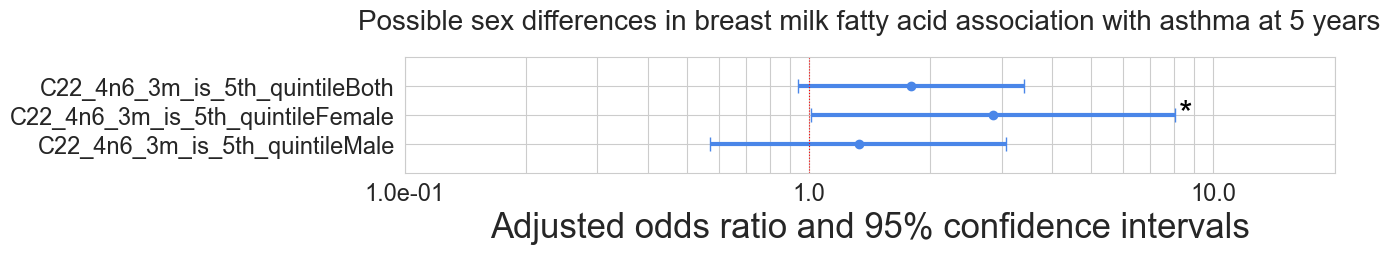

In [197]:

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(12,1.5))
plt.title("Possible sex differences in breast milk fatty acid association with asthma at 5 years",fontsize=20, pad=20)
odds_ratio_table.sort_values(by=["exposure","male_or_female"],inplace=True)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    if "C22" in row['exposure']:    
        
        if row['time outcome assessed']=='5 years' and row['total cases with exposure']>=5:
 
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if 1:
                label = str(row['OR'])

                
                if row['male_or_female']=='Both':
                    plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='#4a86e8', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="#4a86e8", mec="#4a86e8")
                
                if row['male_or_female']=='Male':
                    plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='#4a86e8', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="#4a86e8", mec="#4a86e8")
                if row['male_or_female']=='Female':
                    plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='#4a86e8', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="#4a86e8", mec="#4a86e8")

            
                if row['P-value']<0.01:
                    #label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure']) + ", p="+str(row['P-value'])+" *"
                    label = "**"
                elif row['P-value']<0.05:
                    label = "*"
                else:
                    #label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure']) + ", p="+str(row['P-value'])
                    label = ""
                # Add text to the right of the error bar
                plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure']+ row['male_or_female'], f'{label}', color='black', va='center', fontsize=25)

plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')
plt.xlim(0.1,20)
plt.ylim(-1,3)
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=17)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=25)


plt.show()

## Sex differences in adrenic acid association with asthma at 8 years

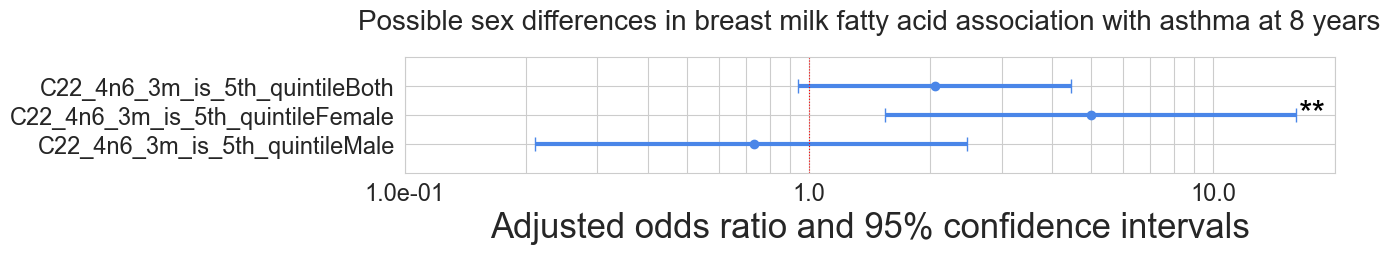

In [198]:

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(12,1.5))
plt.title("Possible sex differences in breast milk fatty acid association with asthma at 8 years",fontsize=20, pad=20)
odds_ratio_table.sort_values(by=["exposure","male_or_female"],inplace=True)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    if "C22" in row['exposure']:    
        
        if row['time outcome assessed']=='8 years' and row['total cases with exposure']>=5:
 
            ci = [[row['OR'] - row['Lower CI']], [row['Upper CI'] - row['OR']]]
            if 1:
                label = str(row['OR'])

                
                if row['male_or_female']=='Both':
                    plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='#4a86e8', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="#4a86e8", mec="#4a86e8")
                
                if row['male_or_female']=='Male':
                    plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='#4a86e8', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="#4a86e8", mec="#4a86e8")
                if row['male_or_female']=='Female':
                    plt.errorbar(x=[row['OR']], y=[row['exposure']+ row['male_or_female']], xerr=ci, ecolor='#4a86e8', capsize=5, linestyle='None', linewidth=3, marker="o", markersize=6, mfc="#4a86e8", mec="#4a86e8")

            
            
                if row['P-value']<0.01:
                    #label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure']) + ", p="+str(row['P-value'])+" *"
                    label = "**"
                elif row['P-value']<0.05:
                    label = "*"
                else:
                    #label = str(row['total exposures']-row['total cases with exposure']) + "/"+str(row['total cases with exposure']) + ", p="+str(row['P-value'])
                    label = ""
                # Add text to the right of the error bar
                plt.text(row['OR'] + ci[1][0] + 0.2, row['exposure']+ row['male_or_female'], f'{label}', color='black', va='center', fontsize=25)

plt.xscale('log',base=10)
# Apply the custom tick label formatting function
ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor')
plt.xlim(0.1,20)
plt.ylim(-1,3)
plt.axvline(x=1, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=17)
plt.xlabel('Adjusted odds ratio and 95% confidence intervals', fontsize=25)


plt.show()